In [204]:
from IPython.display import HTML

HTML("""
<style>
.jp-CodeCell .jp-Cell-inputWrapper {
    display: none !important;
}

.jp-OutputPrompt,
.jp-InputPrompt {
    display: none !important;
}

.jp-RenderedHTMLCommon p {
    line-height: 1.3 !important;
    margin-top: 0.7em !important;
    margin-bottom: 0.7em !important;
}
</style>
""")

<div style="text-align: center; margin-top: 40px; margin-bottom: 45px;">

# Forecasting One-Month-Ahead S&P 500 Returns

### A Comparison of Macroeconomic Predictors and Regression Models

</div>

# Section 1: Introduction

This project examines whether macroeconomic indicators can improve one-month-ahead forecasts of S&P 500 returns using monthly data from 2000 to 2025. The forecasting target is the following month’s S&P 500 return.

An initial set of candidate predictors was collected from FRED, transformed using several methods, and adjusted for publication timing so that each forecast uses only information treated as available at the end of that month.

The predictors were assessed using stationarity tests, while correlation and variance inflation factor screening were conducted on the training set before a final set of five indicators was selected for modelling.

Forecasts were generated using a one-step-ahead forecasting procedure with a historical-mean benchmark, ordinary least squares, Ridge regression, and Lasso regression. Model performance was evaluated using RMSE, MAE, directional accuracy, and out-of-sample R², and robustness was checked across several train–test splits.

# Section 2: Data

In [ ]:
from fredapi import Fred
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import datetime

FRED_API_KEY = "YOUR_FRED_API_KEY_HERE"
fred = Fred(api_key=FRED_API_KEY)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [180]:
START = "1999-01-01"   # pull a little before 2000 so lags/pct_change don't
                        # create NaNs at the very start of your real sample
END   = "2025-12-31"

SAMPLE_START = "2000-01-01"  # the actual analysis sample begins here
SAMPLE_END   = "2025-12-31"


## Data Sources and Candidate Predictors
Ten macroeconomic indicators were collected as the initial predictor set, alongside the S&P 500 return series used as the forecasting target.

| Variable | Source | FRED Series | Native Frequency |
|---|---|---|---|
| S&P 500 return | Yahoo Finance (`^GSPC`) | — | Daily → resampled monthly |
| CPI (inflation) | FRED | `CPIAUCSL` | Monthly |
| PPI | FRED | `PPIACO` | Monthly |
| M2 money supply | FRED | `M2SL` | Monthly |
| CapEx orders | FRED | `NEWORDER` | Monthly |
| Industrial production | FRED | INDPRO | Monthly |
| Unemployment rate | FRED | `UNRATE` | Monthly |
| Consumer sentiment | FRED | `UMCSENT` | Monthly |
| Federal funds rate | FRED | `FEDFUNDS` | Monthly |
| Term spread | FRED | `T10Y3M` | Daily → resampled monthly |
| Credit spread | FRED | `BAA, AAA` | Monthly |

## S&P 500 price and monthly return

This section downloads daily S&P 500 prices, smooths the closing price using a 5-day trailing average, and converts the series to monthly frequency using the final observation of each month. It then calculates monthly returns and creates the one-month-ahead return variable used as the forecasting target. Data was collected beginning in 1999 so that lagged variables and year-over-year percentage changes could be calculated without losing observations from the intended 2000–2025 sample.

Table showing head of the S&P 500 monthly dataset:

In [181]:
sp500_daily = yf.download("^GSPC",start=START, end=END, progress=False, auto_adjust=True)

# 5-day trailing average of daily close
sp500_5day_avg = sp500_daily["Close"].rolling(window=5).mean()

sp500_monthly = sp500_5day_avg.resample("ME").last()
sp500_monthly.name = "sp500_close_5day_avg"

sp500_ret = sp500_monthly.pct_change()
sp500_ret.name = "sp500_ret"

sp500_ret_next = sp500_ret.shift(-1)
sp500_ret_next.name = "sp500_ret_next"

sp500_df = pd.concat([sp500_monthly, sp500_ret, sp500_ret_next],axis=1)
sp500_df.columns = ["sp500_close_5day_avg","sp500_ret","sp500_ret_next"]

sp500_df.head()

,sp500_close_5day_avg,sp500_ret,sp500_ret_next
Date,,,
1999-01-31,1254.894019,NaN,0.000894
1999-02-28,1256.016016,0.000894,0.030254
1999-03-31,1294.016016,0.030254,0.043536
1999-04-30,1350.352026,0.043536,-0.040389
1999-05-31,1295.812012,-0.040389,0.032032


## Candidate Variable Downloads

Data for the ten candidate macroeconomic predictors were downloaded and aligned by date. The table provides a preview of the raw monthly data before any transformations or publication lags were applied.

In [182]:
fred_series = {
    "cpi": "CPIAUCSL",
    "unemployment": "UNRATE",
    "consumer_sentiment": "UMCSENT",
    "m2": "M2SL",
    "capex_orders": "NEWORDER",
    "indpro": "INDPRO",
    "fed_funds_rate": "FEDFUNDS",
    "ppi": "PPIACO",
    "term_spread": "T10Y3M",
    "baa_yield": "BAA",
    "aaa_yield": "AAA"
}

macro_raw = pd.DataFrame()

for variable_name, series_id in fred_series.items():
    macro_raw[variable_name] = fred.get_series(
        series_id,
        observation_start=START,
        observation_end=END
    )

macro_raw.index.name = "date"

macro_raw.head().T.round(4)

date,1999-01-01,1999-02-01,1999-03-01,1999-04-01,1999-05-01
cpi,164.7000,164.700,164.8000,165.9000,166.0000
unemployment,4.3000,4.400,4.2000,4.3000,4.2000
consumer_sentiment,103.9000,108.100,105.7000,104.6000,106.8000
m2,4403.0000,4425.800,4432.6000,4461.4000,4486.1000
capex_orders,57160.0000,58576.000,59657.0000,58929.0000,59814.0000
indpro,87.4949,88.027,88.2267,88.4295,88.9886
fed_funds_rate,4.6300,4.760,4.8100,4.7400,4.7400
ppi,122.9000,122.300,122.6000,123.6000,124.7000
term_spread,NaN,0.220,0.6900,0.8300,NaN
baa_yield,7.2900,7.390,7.5300,7.4800,7.7200


## Predictor Transformations

The candidate variables were given preliminary transformations based on their economic interpretation. CPI, PPI, M2 money supply, capital expenditures, and industrial production were converted to year-over-year percentage growth rates. The unemployment rate, consumer sentiment, federal funds rate, term spread, and credit spread were initially retained in levels.

Isolated one-month gaps were forward-filled using the most recently available observation. This avoids using future values when replacing missing data and keeps the preprocessing consistent with the forecasting setup.

These transformations were only an initial preprocessing step. No formal stationarity testing had been conducted at this stage, so the specifications shown here were not necessarily the final transformations used in the forecasting models.

The table below provides a preview of the monthly data after the preliminary growth and level transformations were applied.

In [183]:
# Convert all series to monthly frequency
macro_monthly = pd.DataFrame()

macro_monthly["cpi"] = macro_raw["cpi"].resample("ME").last()
macro_monthly["unemployment"] = macro_raw["unemployment"].resample("ME").last()
macro_monthly["consumer_sentiment"] = macro_raw["consumer_sentiment"].resample("ME").last()
macro_monthly["m2"] = macro_raw["m2"].resample("ME").last()
macro_monthly["capex_orders"] = macro_raw["capex_orders"].resample("ME").last()
macro_monthly["indpro"] = macro_raw["indpro"].resample("ME").last()
macro_monthly["fed_funds_rate"] = macro_raw["fed_funds_rate"].resample("ME").last()
macro_monthly["ppi"] = macro_raw["ppi"].resample("ME").last()
macro_monthly["term_spread"] = (macro_raw["term_spread"].resample("ME").mean())
macro_monthly["baa_yield"] = macro_raw["baa_yield"].resample("ME").last()
macro_monthly["aaa_yield"] = macro_raw["aaa_yield"].resample("ME").last()
macro_monthly["credit_spread"] = (macro_monthly["baa_yield"] - macro_monthly["aaa_yield"])

# Create cleaned/transformed dataset
macro_clean = pd.DataFrame(index=macro_monthly.index)

# YoY percentage changes
macro_clean["cpi"] = macro_monthly["cpi"].pct_change(12, fill_method=None) * 100
macro_clean["ppi"] = macro_monthly["ppi"].pct_change(12, fill_method=None) * 100
macro_clean["m2"] = macro_monthly["m2"].pct_change(12, fill_method=None) * 100
macro_clean["capex_orders"] = macro_monthly["capex_orders"].pct_change(12, fill_method=None) * 100
macro_clean["indpro"] = macro_monthly["indpro"].pct_change(12, fill_method=None) * 100

# Keep these in levels
macro_clean["unemployment"] = macro_monthly["unemployment"]
macro_clean["consumer_sentiment"] = macro_monthly["consumer_sentiment"]
macro_clean["fed_funds_rate"] = macro_monthly["fed_funds_rate"]
macro_clean["term_spread"] = macro_monthly["term_spread"]
macro_clean["credit_spread"] = macro_monthly["credit_spread"]

# Fill isolated missing monthly observations
macro_clean = macro_clean.ffill(limit=1)

# Drop only any remaining missing rows, usually at the start of the sample
macro_clean = macro_clean.dropna()

macro_clean.head().T.round(4)

date,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31
cpi,2.7930,3.2180,3.7621,3.0139,3.1325
ppi,4.3938,6.1325,6.6884,5.7443,5.5333
m2,6.0095,5.7639,6.2965,6.8678,6.0097
capex_orders,11.9227,-0.1349,6.6799,9.3078,6.5854
indpro,4.6210,4.3133,4.4473,4.8280,4.4515
unemployment,4.0000,4.1000,4.0000,3.8000,4.0000
consumer_sentiment,112.0000,111.3000,107.1000,109.2000,110.7000
fed_funds_rate,5.4500,5.7300,5.8500,6.0200,6.2700
term_spread,0.9400,0.9100,0.6300,0.6300,0.2900
credit_spread,0.5500,0.6100,0.6900,0.7600,0.9100


## Merging Dataframes

The transformed macroeconomic indicators were merged with the S&P 500 dataset using their shared monthly date index. Rows containing missing values were then removed to create a complete dataset for the subsequent variable-selection and forecasting analysis.

The table below previews the initial merged dataset, including the transformed predictors, the five-day average S&P 500 closing price, the monthly return, and the one-month-ahead return used as the forecasting target.

In [184]:
data = pd.concat([macro_clean, sp500_df], axis=1)

data = data.dropna()

data.head().T.round(4)

,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31
cpi,2.7930,3.2180,3.7621,3.0139,3.1325
ppi,4.3938,6.1325,6.6884,5.7443,5.5333
m2,6.0095,5.7639,6.2965,6.8678,6.0097
capex_orders,11.9227,-0.1349,6.6799,9.3078,6.5854
indpro,4.6210,4.3133,4.4473,4.8280,4.4515
unemployment,4.0000,4.1000,4.0000,3.8000,4.0000
consumer_sentiment,112.0000,111.3000,107.1000,109.2000,110.7000
fed_funds_rate,5.4500,5.7300,5.8500,6.0200,6.2700
term_spread,0.9400,0.9100,0.6300,0.6300,0.2900
credit_spread,0.5500,0.6100,0.6900,0.7600,0.9100


## Publication-Lag Treatment of Candidate Predictors

The publication lags below are separate from the one-month-ahead forecasting setup. The target variable is already defined as the S&P 500 return in month \(t+1\), while each row represents the information available by the end of month \(t\). These additional shifts account for whether a month-\(t\) observation was publicly available at the forecast date.

The timing adjustments are applied to all candidate predictors before calculating correlations, VIF values, and selecting the final predictor set.

| Variable | Data timing | Publication lag applied | Reason |
|---|---|---:|---|
| CPI | The month-\(t\) observation is released during month \(t+1\) | 1 month | The month-\(t\) value is not known by the end of month \(t\) |
| PPI | The month-\(t\) observation is released during month \(t+1\) | 1 month | The month-\(t\) value is not known by the end of month \(t\) |
| M2 money supply | The month-\(t\) observation is released during month \(t+1\) | 1 month | The month-\(t\) value is not known by the end of month \(t\) |
| CapEx orders | The month-\(t\) observation is released during month \(t+1\) | 1 month | The month-\(t\) value is not known by the end of month \(t\) |
| Industrial production | The month-\(t\) observation is released during month \(t+1\) | 1 month | The month-\(t\) value is not known by the end of month \(t\) |
| Unemployment rate | The month-\(t\) observation is released during month \(t+1\) | 1 month | The month-\(t\) value is not known by the end of month \(t\) |
| Consumer sentiment | Preliminary and final readings are released during the reference month | 1 month | A conservative lag avoids relying on preliminary or revised within-month information |
| Federal funds rate | The underlying daily effective federal funds rate is observed during month \(t\) | None | The month-\(t\) value is known by the end of month \(t\) |
| Term spread | Constructed from daily Treasury yields available during month \(t\) | None | The monthly average through the end of month \(t\) is known at the forecast date |
| Credit spread | Constructed from monthly Baa and Aaa corporate-yield series | 1 month | The monthly observation is treated conservatively as unavailable until the following month |

Therefore, CPI, PPI, M2, CapEx orders, industrial production, unemployment, consumer sentiment, and the credit spread are shifted by one month. The federal funds rate and term spread are left unshifted because their underlying market information is available by month-end. The resulting aligned predictors are then used to examine correlations with the S&P 500 return in the following month.

In [185]:
# Apply publication lags to candidate predictors

data["cpi"] = data["cpi"].shift(1)
data["ppi"] = data["ppi"].shift(1)
data["m2"] = data["m2"].shift(1)
data["capex_orders"] = data["capex_orders"].shift(1)
data["indpro"] = data["indpro"].shift(1)
data["unemployment"] = data["unemployment"].shift(1)
data["consumer_sentiment"] = data["consumer_sentiment"].shift(1)
data["credit_spread"] = data["credit_spread"].shift(1)

# No publication lag
# data["fed_funds_rate"] stays unchanged
# data["term_spread"] stays unchanged

data = data.dropna()

data.head().T.round(4)

,2000-02-29,2000-03-31,2000-04-30,2000-05-31,2000-06-30
cpi,2.7930,3.2180,3.7621,3.0139,3.1325
ppi,4.3938,6.1325,6.6884,5.7443,5.5333
m2,6.0095,5.7639,6.2965,6.8678,6.0097
capex_orders,11.9227,-0.1349,6.6799,9.3078,6.5854
indpro,4.6210,4.3133,4.4473,4.8280,4.4515
unemployment,4.0000,4.1000,4.0000,3.8000,4.0000
consumer_sentiment,112.0000,111.3000,107.1000,109.2000,110.7000
fed_funds_rate,5.7300,5.8500,6.0200,6.2700,6.5300
term_spread,0.9100,0.6300,0.6300,0.2900,0.4600
credit_spread,0.5500,0.6100,0.6900,0.7600,0.9100


The table below shows the predictor values available at each month-end after accounting for publication timing. These values are used to forecast the following month’s S&P 500 return.

## Stationarity and Predictor Screening

The candidate predictors were tested for stationarity using the Augmented Dickey–Fuller (ADF) and KPSS tests. The table below reports the p-values and stationarity conclusions from both tests for each variable.

In [186]:
predictors = [
    "cpi",
    "ppi",
    "m2",
    "capex_orders",
    "indpro",
    "unemployment",
    "consumer_sentiment",
    "fed_funds_rate",
    "term_spread",
    "credit_spread"
]

stationarity_results = []

for variable in predictors:
    series = data[variable].dropna()

    adf_result = adfuller(series, autolag="AIC")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_result = kpss(
            series,
            regression="c",
            nlags="auto"
        )

    stationarity_results.append({
        "variable": variable,
        "ADF p-value": adf_result[1],
        "KPSS p-value": kpss_result[1],
        "ADF conclusion": (
            "Stationary" if adf_result[1] < 0.05 else "Non-stationary"
        ),
        "KPSS conclusion": (
            "Stationary" if kpss_result[1] > 0.05 else "Non-stationary"
        )
    })

stationarity_results = pd.DataFrame(stationarity_results)

stationarity_results

,variable,ADF p-value,KPSS p-value,ADF conclusion,KPSS conclusion
0,cpi,0.021094,0.100000,Stationary,Stationary
1,ppi,0.000122,0.100000,Stationary,Stationary
2,m2,0.011386,0.100000,Stationary,Stationary
3,capex_orders,0.000471,0.100000,Stationary,Stationary
4,indpro,0.001167,0.100000,Stationary,Stationary
5,unemployment,0.024567,0.066852,Stationary,Stationary
6,consumer_sentiment,0.284899,0.022512,Non-stationary,Non-stationary
7,fed_funds_rate,0.002293,0.076304,Stationary,Stationary
8,term_spread,0.395605,0.012795,Non-stationary,Non-stationary
9,credit_spread,0.000445,0.100000,Stationary,Stationary


Most predictors were classified as stationary under both tests. Consumer sentiment and the term spread were identified as non-stationary, so they were converted to monthly first differences before the tests were repeated.

In [187]:
# Convert the non-stationary level variables to monthly first differences
data["consumer_sentiment"] = data["consumer_sentiment"].diff()
data["term_spread"] = data["term_spread"].diff()

# Remove the first row made missing by differencing
data = data.dropna()

# Repeat ADF and KPSS tests after the transformations
revised_stationarity_results = []

for variable in predictors:
    series = data[variable].dropna()

    adf_result = adfuller(series, autolag="AIC")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_result = kpss(
            series,
            regression="c",
            nlags="auto"
        )

    revised_stationarity_results.append({
        "variable": variable,
        "ADF p-value": adf_result[1],
        "KPSS p-value": kpss_result[1],
        "ADF conclusion": (
            "Stationary" if adf_result[1] < 0.05 else "Non-stationary"
        ),
        "KPSS conclusion": (
            "Stationary" if kpss_result[1] > 0.05 else "Non-stationary"
        )
    })

revised_stationarity_results = pd.DataFrame(
    revised_stationarity_results
)

revised_stationarity_results

,variable,ADF p-value,KPSS p-value,ADF conclusion,KPSS conclusion
0,cpi,2.065556e-02,0.100000,Stationary,Stationary
1,ppi,1.264471e-04,0.100000,Stationary,Stationary
2,m2,1.162229e-02,0.100000,Stationary,Stationary
3,capex_orders,4.238221e-04,0.100000,Stationary,Stationary
4,indpro,1.307561e-03,0.100000,Stationary,Stationary
5,unemployment,2.516725e-02,0.065068,Stationary,Stationary
6,consumer_sentiment,8.611355e-12,0.100000,Stationary,Stationary
7,fed_funds_rate,2.250195e-03,0.079830,Stationary,Stationary
8,term_spread,9.780645e-29,0.100000,Stationary,Stationary
9,credit_spread,5.054430e-04,0.100000,Stationary,Stationary


After applying the revised transformations, all predictor variables are classified as stationary under both the ADF and KPSS tests. These transformed series are therefore retained for the subsequent predictor-screening and forecasting analysis.

## Final Variable Transformations

The table below summarizes the final transformation applied to each predictor after the stationarity tests were completed. It also provides a brief interpretation of what each transformed variable represents in the forecasting dataset.
| Variable | Transformation used | Interpretation |
|---|---|---|
| CPI | Year-over-year percentage growth | Annual CPI inflation rate |
| PPI | Year-over-year percentage growth | Annual producer-price inflation rate |
| M2 money supply | Year-over-year percentage growth | Annual growth in the money supply |
| CapEx orders | Year-over-year percentage growth | Annual growth in new capital-goods orders |
| Industrial production | Year-over-year percentage growth | Annual growth in industrial production |
| Unemployment rate | Level | Monthly unemployment rate |
| Consumer sentiment | First difference | Monthly change in the consumer sentiment index |
| Federal funds rate | Level | Monthly average effective federal funds rate |
| Term spread | First difference | Monthly change in the 10-year minus 3-month Treasury spread |
| Credit spread | Level | Difference between Baa and Aaa corporate bond yields |

# Section 3: Predictor Screening and Selection

## Correlation Screening

The correlations between each transformed predictor and the one-month-ahead S&P 500 return were calculated using only the initial training sample. Restricting the screening to the training sample prevents the testing period from influencing variable selection and provides a more credible measure of out-of-sample performance. The results are ordered by absolute correlation so that the predictors with the strongest individual relationships with next-month returns appear first.

In [ ]:
screen_split_index = int(len(data) * 0.80)
screening_data = data.iloc[:screen_split_index]

correlations = (
    screening_data[predictors]
    .corrwith(screening_data["sp500_ret_next"])
    .sort_values(key=abs, ascending=False)
)

correlations

cpi                  -0.208330
ppi                  -0.166676
fed_funds_rate       -0.132702
term_spread          -0.117672
unemployment          0.112041
m2                    0.088391
credit_spread        -0.056584
consumer_sentiment    0.025514
indpro               -0.011990
capex_orders          0.004420
dtype: float64

Overall, the correlations are weak. CPI and PPI have the largest absolute correlations, while consumer sentiment and capital expenditures have relationships close to zero. Correlation is used only as an initial screening tool and does not by itself establish that a variable will improve out-of-sample forecasts.

## VIF Analysis

Variance inflation factors were calculated for the full set of candidate predictors to identify variables containing highly overlapping information. A high VIF indicates that a predictor is strongly related to other predictors, which can make regression coefficients unstable.

In [189]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = screening_data[predictors].dropna()

X_with_constant = add_constant(X)

vif_results = pd.DataFrame({
    "variable": X_with_constant.columns,
    "VIF": [
        variance_inflation_factor(X_with_constant.values, i)
        for i in range(X_with_constant.shape[1])
    ]
})

vif_results = (
    vif_results
    .query("variable != 'const'")
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

vif_results

,variable,VIF
0,ppi,9.908273
1,cpi,8.811029
2,indpro,4.492189
3,capex_orders,4.143242
4,unemployment,2.363302
5,fed_funds_rate,2.041438
6,m2,1.985962
7,credit_spread,1.800385
8,term_spread,1.105217
9,consumer_sentiment,1.048947


Based on the training-sample correlation and VIF results, the final predictor set consists of CPI, the term spread, the credit spread, the unemployment rate, and the federal funds rate. PPI was removed because it contained highly overlapping information with CPI and had both a weaker correlation with next-month returns and a higher VIF. M2 money supply, capital expenditures, industrial production, and consumer sentiment were removed because their correlations with next-month returns were comparatively weak.

In [190]:
final_predictors = [
    "cpi",
    "fed_funds_rate",
    "term_spread",
    "unemployment",
    "credit_spread"
]

X_final = data[final_predictors].dropna()
X_final_constant = add_constant(X_final)

final_vif = pd.DataFrame({
    "variable": X_final_constant.columns,
    "VIF": [
        variance_inflation_factor(X_final_constant.values, i)
        for i in range(X_final_constant.shape[1])
    ]
})

final_vif = (
    final_vif
    .query("variable != 'const'")
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

final_vif

,variable,VIF
0,unemployment,1.870923
1,fed_funds_rate,1.602691
2,cpi,1.271564
3,credit_spread,1.190553
4,term_spread,1.008547


The VIF values were then recalculated for the final predictor set. All five values are low, indicating that the retained predictors do not create a meaningful multicollinearity problem.

## Final Predictor Set

The final modelling dataset contains the five predictors retained after the training-sample correlation and VIF screening: CPI, the term spread, the credit spread, the unemployment rate, and the federal funds rate. These variables are combined with the one-month-ahead S&P 500 return, which serves as the forecasting target.

The table below previews the completed dataset that will be used to estimate and evaluate the forecasting models.

In [191]:
model_data = data[
    final_predictors + ["sp500_ret_next"]
].dropna()

model_data.head()

,cpi,fed_funds_rate,term_spread,unemployment,credit_spread,sp500_ret_next
2000-03-31,3.217972,5.85,-0.28,4.1,0.61,-0.032016
2000-04-30,3.762136,6.02,0.00,4.0,0.69,-0.038981
2000-05-31,3.013864,6.27,-0.34,3.8,0.76,0.036567
2000-06-30,3.132530,6.53,0.17,4.0,0.91,-0.004194
2000-07-31,3.734940,6.54,0.00,4.0,0.81,0.044750


# Section 4: Summary Statistics

## Descriptive Statistics Table

The table below summarizes the final predictors and the one-month-ahead S&P 500 return using the number of observations, mean, standard deviation, minimum, quartiles, and maximum. These statistics provide an initial comparison of each variable’s typical value, variability, and overall range before the forecasting models are estimated.

In [202]:
variable_labels = {
    "cpi": "CPI Inflation (YoY %)",
    "term_spread": "Change in Term Spread",
    "credit_spread": "Credit Spread (Percentage Points)",
    "unemployment": "Unemployment Rate (%)",
    "fed_funds_rate": "Federal Funds Rate (%)",
    "sp500_ret_next": "Next-Month S&P 500 Return (Decimal)"
}

summary_stats = (
    model_data.describe().T[
        ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
    ]
    .rename(index=variable_labels)
    .rename(columns={
        "count": "N",
        "mean": "Mean",
        "std": "Std. Dev.",
        "min": "Minimum",
        "25%": "25th Percentile",
        "50%": "Median",
        "75%": "75th Percentile",
        "max": "Maximum"
    })
    .round(4)
)

summary_stats

,N,Mean,Std. Dev.,Minimum,25th Percentile,Median,75th Percentile,Maximum
CPI Inflation (YoY %),288.0,2.6409,1.7572,-1.9588,1.6808,2.3778,3.3537,8.9794
Federal Funds Rate (%),288.0,2.0172,2.0463,0.0500,0.1500,1.2600,4.0225,6.5400
Change in Term Spread,288.0,-0.0028,0.2969,-1.1100,-0.1100,0.0000,0.0600,1.3500
Unemployment Rate (%),288.0,5.6569,1.9777,3.4000,4.2000,5.0000,6.2250,14.8000
Credit Spread (Percentage Points),288.0,1.0012,0.3748,0.5500,0.7700,0.9200,1.1150,3.3800
Next-Month S&P 500 Return (Decimal),288.0,0.0060,0.0420,-0.2106,-0.0171,0.0134,0.0329,0.0952


The variables differ noticeably in scale and variability. CPI inflation and the unemployment rate show particularly wide ranges, while changes in the term spread are centered close to zero. The average next-month S&P 500 return is positive, but its minimum and maximum show that monthly returns can vary substantially.

## Distribution of Next-Month S&P 500 Returns

The histogram below shows the distribution of the one-month-ahead S&P 500 return used as the forecasting target. The dashed vertical line marks the average return and provides a reference point for the historical-mean benchmark used later in the analysis.

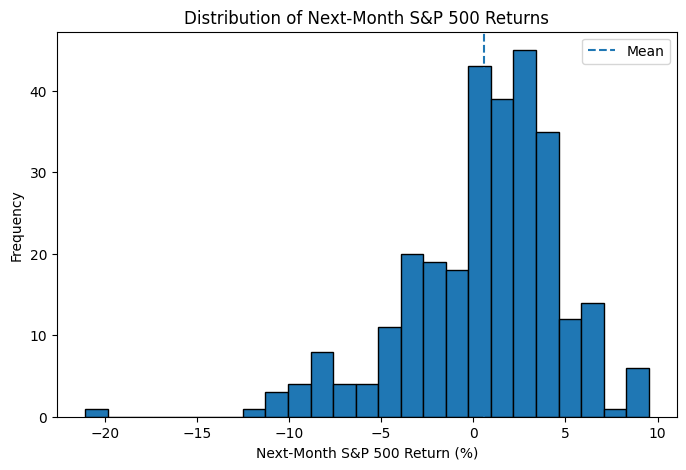

In [193]:
plt.figure(figsize=(8, 5))

plt.hist(
    model_data["sp500_ret_next"] * 100,
    bins=25,
    edgecolor="black"
)

plt.axvline(
    model_data["sp500_ret_next"].mean() * 100,
    linestyle="--",
    linewidth=1.5,
    label="Mean"
)

plt.xlabel("Next-Month S&P 500 Return (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Next-Month S&P 500 Returns")
plt.legend()

plt.show()

The distribution of next-month S&P 500 returns is centered slightly above zero, with most observations falling between roughly −5% and 5%. The distribution is negatively skewed because of a small number of large negative returns, including one extreme observation near −20%. Positive returns occur more frequently than negative returns, which helps explain why the historical-mean benchmark achieves relatively high directional accuracy despite making fairly simple forecasts.

# Section 5: Modelling

## Train–Test Split

The dataset is divided chronologically into an 80% training sample and a 20% testing sample. The earlier observations are used to estimate the forecasting models, while the later observations are reserved for evaluating their out-of-sample performance.

The output reports the date range and number of observations in each sample. This preserves the time ordering of the data and avoids using future information when generating forecasts.

In [194]:
split_index = int(len(model_data) * 0.80)

train_data = model_data.iloc[:split_index]
test_data = model_data.iloc[split_index:]

print("Training period:", train_data.index.min(), "to", train_data.index.max())
print("Testing period:", test_data.index.min(), "to", test_data.index.max())
print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

X_train = train_data[final_predictors]
y_train = train_data["sp500_ret_next"]

X_test = test_data[final_predictors]
y_test = test_data["sp500_ret_next"]

Training period: 2000-03-31 00:00:00 to 2020-10-31 00:00:00
Testing period: 2020-11-30 00:00:00 to 2025-11-30 00:00:00
Training observations: 230
Testing observations: 58


## Historical-Mean Benchmark

The historical-mean benchmark forecasts each test-period return using the average of all next-month S&P 500 returns available up to that point. This expanding-window approach ensures that each prediction uses only past information.

The benchmark is evaluated using RMSE, MAE, and directional accuracy. These results provide the baseline that the OLS, Ridge, and Lasso models must outperform to demonstrate useful predictive value.

In [195]:
benchmark_forecasts = []

for i in range(len(test_data)):
    available_data = model_data.iloc[:split_index + i]
    benchmark_forecasts.append(
        available_data["sp500_ret_next"].mean()
    )

benchmark_forecasts = pd.Series(
    benchmark_forecasts,
    index=test_data.index,
    name="benchmark_forecast"
)


from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

benchmark_rmse = np.sqrt(
    mean_squared_error(y_test, benchmark_forecasts)
)

benchmark_mae = mean_absolute_error(
    y_test, benchmark_forecasts
)

benchmark_directional_accuracy = (
    np.sign(benchmark_forecasts) == np.sign(y_test)
).mean()

print("Benchmark RMSE:", benchmark_rmse)
print("Benchmark MAE:", benchmark_mae)
print("Benchmark Directional Accuracy:", benchmark_directional_accuracy)


Benchmark RMSE: 0.03881634801602794
Benchmark MAE: 0.03213827849489971
Benchmark Directional Accuracy: 0.7241379310344828


## OLS Regression

The OLS model estimates the relationship between the selected predictors and the one-month-ahead S&P 500 return using the training data available at each point in time. An expanding-window procedure is used so that the model is re-estimated before each forecast using only information that would have been available at that date. The resulting forecasts are evaluated using RMSE, MAE, directional accuracy, and out-of-sample R².

In [196]:
from sklearn.linear_model import LinearRegression

ols_forecasts = []

for i in range(len(test_data)):
    expanding_data = model_data.iloc[:split_index + i]

    X_expanding = expanding_data[final_predictors]
    y_expanding = expanding_data["sp500_ret_next"]

    ols_model = LinearRegression()
    ols_model.fit(X_expanding, y_expanding)

    next_X = test_data[final_predictors].iloc[[i]]
    ols_forecasts.append(
        ols_model.predict(next_X)[0]
    )

ols_forecasts = pd.Series(
    ols_forecasts,
    index=test_data.index,
    name="ols_forecast"
)



ols_rmse = np.sqrt(
    mean_squared_error(y_test, ols_forecasts)
)

ols_mae = mean_absolute_error(
    y_test, ols_forecasts
)

ols_directional_accuracy = (
    np.sign(ols_forecasts) == np.sign(y_test)
).mean()

ols_oos_r2 = 1 - (
    np.sum((y_test - ols_forecasts) ** 2)
    / np.sum((y_test - benchmark_forecasts) ** 2)
)

print("OLS RMSE:", ols_rmse)
print("OLS MAE:", ols_mae)
print("OLS Directional Accuracy:", ols_directional_accuracy)
print("OLS Out-of-Sample R²:", ols_oos_r2)

OLS RMSE: 0.04219430121796235
OLS MAE: 0.033674548769471443
OLS Directional Accuracy: 0.5862068965517241
OLS Out-of-Sample R²: -0.18162113917278466


## Ridge Regression

The Ridge model applies a penalty that reduces the size of the estimated coefficients, which can help limit overfitting when predictors contain overlapping information. The predictors are standardized so that the penalty is applied consistently across variables measured on different scales. Using the same expanding-window forecasting procedure as OLS, the penalty strength is selected through cross-validation and performance is evaluated using RMSE, MAE, directional accuracy, out-of-sample R².

In [197]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV

ridge_forecasts = []

ridge_alphas = np.logspace(-4, 4, 100)

for i in range(len(test_data)):
    expanding_data = model_data.iloc[:split_index + i]

    X_expanding = expanding_data[final_predictors]
    y_expanding = expanding_data["sp500_ret_next"]

    ridge_model = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=ridge_alphas)
    )

    ridge_model.fit(X_expanding, y_expanding)

    next_X = test_data[final_predictors].iloc[[i]]
    ridge_forecasts.append(
        ridge_model.predict(next_X)[0]
    )

ridge_forecasts = pd.Series(
    ridge_forecasts,
    index=test_data.index,
    name="ridge_forecast"
)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_forecasts)
)

ridge_mae = mean_absolute_error(
    y_test, ridge_forecasts
)

ridge_directional_accuracy = (
    np.sign(ridge_forecasts) == np.sign(y_test)
).mean()

ridge_oos_r2 = 1 - (
    np.sum((y_test - ridge_forecasts) ** 2)
    / np.sum((y_test - benchmark_forecasts) ** 2)
)

print("Ridge RMSE:", ridge_rmse)
print("Ridge MAE:", ridge_mae)
print("Ridge Directional Accuracy:", ridge_directional_accuracy)
print("Ridge Out-of-Sample R²:", ridge_oos_r2)

Ridge RMSE: 0.040430016471645354
Ridge MAE: 0.0332296620546653
Ridge Directional Accuracy: 0.6206896551724138
Ridge Out-of-Sample R²: -0.08487197551038639


## Lasso Regression

The Lasso model applies a penalty that can shrink some coefficient estimates to zero, allowing it to reduce the influence of weaker predictors and limit overfitting. The predictors are standardized so that the penalty is applied consistently across variables measured on different scales. Using the same expanding-window forecasting procedure as the other models, the penalty strength is selected through cross-validation and performance is evaluated using RMSE, MAE, directional accuracy, and out-of-sample R².

In [198]:
from sklearn.linear_model import LassoCV

lasso_forecasts = []

lasso_alphas = np.logspace(-6, 0, 100)

for i in range(len(test_data)):
    expanding_data = model_data.iloc[:split_index + i]

    X_expanding = expanding_data[final_predictors]
    y_expanding = expanding_data["sp500_ret_next"]

    lasso_model = make_pipeline(
        StandardScaler(),
        LassoCV(
            alphas=lasso_alphas,
            cv=5,
            max_iter=100000
        )
    )

    lasso_model.fit(X_expanding, y_expanding)

    next_X = test_data[final_predictors].iloc[[i]]
    lasso_forecasts.append(
        lasso_model.predict(next_X)[0]
    )

lasso_forecasts = pd.Series(
    lasso_forecasts,
    index=test_data.index,
    name="lasso_forecast"
)

lasso_rmse = np.sqrt(
    mean_squared_error(y_test, lasso_forecasts)
)

lasso_mae = mean_absolute_error(
    y_test, lasso_forecasts
)

lasso_directional_accuracy = (
    np.sign(lasso_forecasts) == np.sign(y_test)
).mean()

lasso_oos_r2 = 1 - (
    np.sum((y_test - lasso_forecasts) ** 2)
    / np.sum((y_test - benchmark_forecasts) ** 2)
)

print("Lasso RMSE:", lasso_rmse)
print("Lasso MAE:", lasso_mae)
print("Lasso Directional Accuracy:", lasso_directional_accuracy)
print("Lasso Out-of-Sample R²:", lasso_oos_r2)

Lasso RMSE: 0.04032668708977766
Lasso MAE: 0.033607489954134824
Lasso Directional Accuracy: 0.603448275862069
Lasso Out-of-Sample R²: -0.07933371897752961


# Section 6: Model Comparison

## Model Comparison Table

The table below compares the historical-mean benchmark, OLS, Ridge, and Lasso using RMSE, MAE, directional accuracy, and out-of-sample R². Using the same evaluation measures across all four approaches makes it possible to assess whether the predictive models improve on the benchmark.

In [199]:
model_comparison = pd.DataFrame({
    "RMSE": [
        benchmark_rmse,
        ols_rmse,
        ridge_rmse,
        lasso_rmse
    ],
    "MAE": [
        benchmark_mae,
        ols_mae,
        ridge_mae,
        lasso_mae
    ],
    "Directional Accuracy": [
        benchmark_directional_accuracy,
        ols_directional_accuracy,
        ridge_directional_accuracy,
        lasso_directional_accuracy
    ],
    "Out-of-Sample R²": [
        0,
        ols_oos_r2,
        ridge_oos_r2,
        lasso_oos_r2
    ]
}, index=[
    "Historical-Mean Benchmark",
    "OLS",
    "Ridge",
    "Lasso"
])

model_comparison.round(4)

,RMSE,MAE,Directional Accuracy,Out-of-Sample R²
Historical-Mean Benchmark,0.0388,0.0321,0.7241,0.0000
OLS,0.0422,0.0337,0.5862,-0.1816
Ridge,0.0404,0.0332,0.6207,-0.0849
Lasso,0.0403,0.0336,0.6034,-0.0793


The historical-mean benchmark produced the strongest overall performance, with the lowest RMSE and MAE and the highest directional accuracy. OLS performed worst, while Ridge and Lasso reduced the forecast errors somewhat but still failed to outperform the benchmark.

All three regression models produced negative out-of-sample R² values, indicating that the selected predictors did not improve forecast accuracy relative to the historical average return. Ridge and Lasso performed similarly, with Lasso producing a slightly lower RMSE and Ridge producing a slightly lower MAE.

## Visual Comparison of Model Forecasts

The first plot compares the actual one-month-ahead S&P 500 returns with the forecasts from OLS, Ridge, and Lasso over the test period. The second plot removes the actual return series and focuses only on the model forecasts, making it easier to compare how the three models differ in their predicted movements.

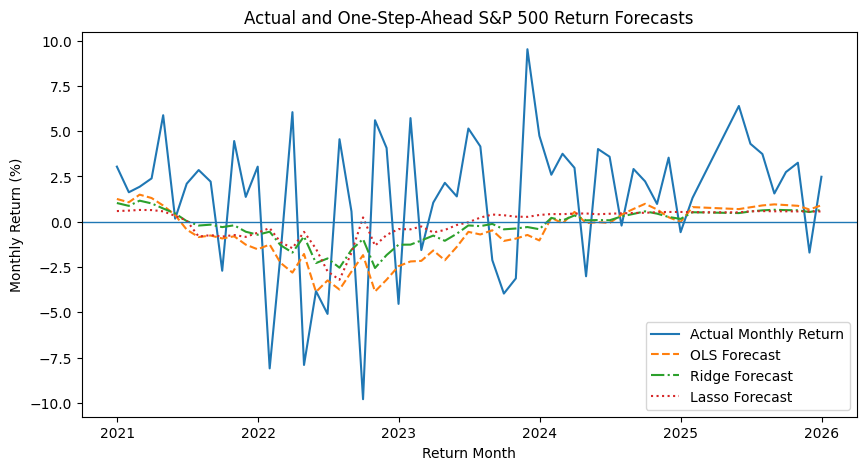

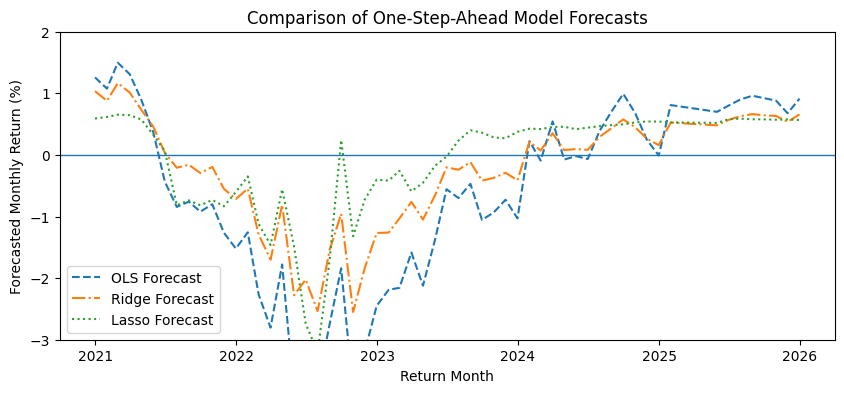

In [200]:
plot_dates = y_test.index + pd.offsets.MonthEnd(1)

# Actual returns and all model forecasts
plt.figure(figsize=(10, 5))

plt.plot(
    plot_dates,
    y_test * 100,
    label="Actual Monthly Return"
)

plt.plot(
    plot_dates,
    ols_forecasts * 100,
    label="OLS Forecast",
    linestyle="--"
)

plt.plot(
    plot_dates,
    ridge_forecasts * 100,
    label="Ridge Forecast",
    linestyle="-."
)

plt.plot(
    plot_dates,
    lasso_forecasts * 100,
    label="Lasso Forecast",
    linestyle=":"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Return Month")
plt.ylabel("Monthly Return (%)")
plt.title("Actual and One-Step-Ahead S&P 500 Return Forecasts")
plt.legend()
plt.show()


# Zoomed-in comparison of model forecasts
plt.figure(figsize=(10, 4))

plt.plot(
    plot_dates,
    ols_forecasts * 100,
    label="OLS Forecast",
    linestyle="--"
)

plt.plot(
    plot_dates,
    ridge_forecasts * 100,
    label="Ridge Forecast",
    linestyle="-."
)

plt.plot(
    plot_dates,
    lasso_forecasts * 100,
    label="Lasso Forecast",
    linestyle=":"
)

plt.axhline(0, linewidth=1)
plt.ylim(-3, 2)

plt.xlabel("Return Month")
plt.ylabel("Forecasted Monthly Return (%)")
plt.title("Comparison of One-Step-Ahead Model Forecasts")
plt.legend()
plt.show()

The first figure shows that all three forecasting models produce much smoother predictions than the realized monthly S&P 500 returns. None of the models captures the large positive and negative movements observed during the test period, which is consistent with their weak out-of-sample performance.

The second figure highlights the differences across the model forecasts. OLS produces the most variable predictions and reacts most strongly to changes in the selected predictors. Ridge reduces some of this variation through coefficient shrinkage, while Lasso produces slightly smoother forecasts. Despite these differences, all three models fail to match the volatility of actual monthly returns and do not outperform the historical-mean benchmark.

# Section 7: Robustness Check

To test whether the main findings depend on the chosen 80/20 train–test split, the forecasting exercise is repeated using 60/40 and 70/30 splits. The same expanding-window procedure and evaluation measures are used for each specification, allowing the model rankings to be compared across different testing periods.

In [201]:
split_ratios = [0.60, 0.70, 0.80]

split_labels = {
    0.60: "60/40",
    0.70: "70/30",
    0.80: "80/20"
}

robustness_results = []


def evaluate_forecasts(actual, forecasts, benchmark):
    rmse = np.sqrt(mean_squared_error(actual, forecasts))
    mae = mean_absolute_error(actual, forecasts)

    directional_accuracy = (
        np.sign(forecasts) == np.sign(actual)
    ).mean()

    oos_r2 = 1 - (
        np.sum((actual - forecasts) ** 2)
        / np.sum((actual - benchmark) ** 2)
    )

    return rmse, mae, directional_accuracy, oos_r2


for split_ratio in split_ratios:
    robust_split_index = int(len(model_data) * split_ratio)

    robust_test_data = model_data.iloc[robust_split_index:]
    robust_y_test = robust_test_data["sp500_ret_next"]

    robust_benchmark_forecasts = []
    robust_ols_forecasts = []
    robust_ridge_forecasts = []
    robust_lasso_forecasts = []

    for i in range(len(robust_test_data)):
        expanding_data = model_data.iloc[:robust_split_index + i]

        X_expanding = expanding_data[final_predictors]
        y_expanding = expanding_data["sp500_ret_next"]

        next_X = robust_test_data[final_predictors].iloc[[i]]

        robust_benchmark_forecasts.append(
            y_expanding.mean()
        )

        ols_model = LinearRegression()
        ols_model.fit(X_expanding, y_expanding)

        robust_ols_forecasts.append(
            ols_model.predict(next_X)[0]
        )

        ridge_model = make_pipeline(
            StandardScaler(),
            RidgeCV(alphas=ridge_alphas)
        )

        ridge_model.fit(X_expanding, y_expanding)

        robust_ridge_forecasts.append(
            ridge_model.predict(next_X)[0]
        )

        lasso_model = make_pipeline(
            StandardScaler(),
            LassoCV(
                alphas=lasso_alphas,
                cv=5,
                max_iter=100000
            )
        )

        lasso_model.fit(X_expanding, y_expanding)

        robust_lasso_forecasts.append(
            lasso_model.predict(next_X)[0]
        )

    forecast_index = robust_test_data.index

    robust_benchmark_forecasts = pd.Series(
        robust_benchmark_forecasts,
        index=forecast_index
    )

    robust_ols_forecasts = pd.Series(
        robust_ols_forecasts,
        index=forecast_index
    )

    robust_ridge_forecasts = pd.Series(
        robust_ridge_forecasts,
        index=forecast_index
    )

    robust_lasso_forecasts = pd.Series(
        robust_lasso_forecasts,
        index=forecast_index
    )

    model_forecasts = {
        "Historical-Mean Benchmark": robust_benchmark_forecasts,
        "OLS": robust_ols_forecasts,
        "Ridge": robust_ridge_forecasts,
        "Lasso": robust_lasso_forecasts
    }

    for model_name, forecasts in model_forecasts.items():
        rmse, mae, directional_accuracy, oos_r2 = evaluate_forecasts(
            robust_y_test,
            forecasts,
            robust_benchmark_forecasts
        )

        robustness_results.append({
            "Train-Test Split": split_labels[split_ratio],
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "Directional Accuracy": directional_accuracy,
            "Out-of-Sample R²": oos_r2
        })


robustness_results = pd.DataFrame(robustness_results)


for split_name in ["60/40", "70/30", "80/20"]:
    print(f"\n{split_name} Train-Test Split")

    split_table = (
        robustness_results[
            robustness_results["Train-Test Split"] == split_name
        ]
        .set_index("Model")
        .drop(columns="Train-Test Split")
        .round(4)
    )

    display(split_table)


60/40 Train-Test Split


,RMSE,MAE,Directional Accuracy,Out-of-Sample R²
Model,,,,
Historical-Mean Benchmark,0.0392,0.0312,0.7414,0.0000
OLS,0.0407,0.0322,0.5948,-0.0790
Ridge,0.0397,0.0317,0.6379,-0.0258
Lasso,0.0398,0.0319,0.6810,-0.0323



70/30 Train-Test Split


,RMSE,MAE,Directional Accuracy,Out-of-Sample R²
Model,,,,
Historical-Mean Benchmark,0.0410,0.0335,0.7471,0.0000
OLS,0.0430,0.0346,0.5977,-0.0973
Ridge,0.0418,0.0341,0.6207,-0.0402
Lasso,0.0419,0.0344,0.6667,-0.0426



80/20 Train-Test Split


,RMSE,MAE,Directional Accuracy,Out-of-Sample R²
Model,,,,
Historical-Mean Benchmark,0.0388,0.0321,0.7241,0.0000
OLS,0.0422,0.0337,0.5862,-0.1816
Ridge,0.0404,0.0332,0.6207,-0.0849
Lasso,0.0403,0.0336,0.6034,-0.0793


The robustness results are consistent across all three train–test splits. OLS underperforms the historical-mean benchmark in every case. Ridge and Lasso generally improve on OLS, but neither model consistently outperforms the benchmark.

All three regression models produce negative out-of-sample R² values across the alternative splits, indicating that the selected predictors do not improve forecast accuracy relative to the historical average return. Ridge and Lasso perform similarly, with their relative ranking changing slightly depending on the evaluation measure and train–test split.

Overall, the main conclusion is stable across different forecast starting points: the selected macroeconomic indicators provide little additional one-month-ahead predictive value beyond the historical-mean benchmark.

# Section 8: Discussion and Conclusion

The goal of this project was to determine whether a small group of macroeconomic indicators could improve one-month-ahead forecasts of S&P 500 returns.

The results were consistent across the models. OLS produced the weakest forecasts, while Ridge and Lasso reduced the forecast errors somewhat through coefficient shrinkage. However, all three regression models still performed worse than the historical-mean benchmark.

Each regression model produced a negative out-of-sample R², indicating that the selected predictors did not improve forecast accuracy relative to the historical average return. The forecast graphs also showed that none of the models captured the larger month-to-month movements in actual returns particularly well.

The robustness checks using alternative train–test splits produced the same general conclusion. OLS continued to underperform, while Ridge and Lasso generally improved on OLS but still failed to consistently outperform the benchmark. This suggests that the main result is not driven entirely by the original 80/20 split.

Overall, the selected macroeconomic indicators provided little additional predictive value for monthly S&P 500 returns. The historical-mean benchmark remained the strongest forecasting approach, showing how difficult it is to improve on a simple average when predicting short-horizon stock returns.

Future work could examine alternative predictors, nonlinear methods, rolling estimation windows, or higher-frequency financial data to determine whether these approaches improve out-of-sample performance.